In [1]:
import gdown
import zipfile
import os

# Google Drive file ID from the link
file_id = '1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'dataset.zip'

# Download the file
gdown.download(url, output, quiet=False)

# Extract the zip file
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('dataset_content')

print("Extraction complete.")

Downloading...
From (original): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ
From (redirected): https://drive.google.com/uc?id=1ZEyNMEO43u3qhJAwJeBZxFBEYc_pVYZQ&confirm=t&uuid=23c98159-80a6-401d-832d-452ab00175f6
To: /content/dataset.zip
100%|██████████| 1.13G/1.13G [00:04<00:00, 227MB/s]


Extraction complete.


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F

import torchvision.models as models
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [14]:
class LensDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        self.labels = []

        self.classes = ['no', 'sphere', 'vort']

        for label, cls in enumerate(self.classes):
            path = os.path.join(root_dir, cls)

            for file in os.listdir(path):
                if file.endswith(".npy"):
                    self.data.append(os.path.join(path, file))
                    self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = np.load(self.data[idx])

        # Normalize
        img = (img - img.min()) / (img.max() - img.min() + 1e-8) # Added a tiny number to prevent divide-by-zero errors

        img = torch.tensor(img, dtype=torch.float32)

        # Ensure shape (1, H, W)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)


        # ---> THE NEW RESIZE LINE <---
        img = F.resize(img, [300, 300], antialias=True)
        #print("Converting the 150*150 to 300*300 was Successfully ! ")

        # Convert to 3 channels
        img = img.repeat(3, 1, 1)

        label = torch.tensor(self.labels[idx])

        return img, label

In [15]:
train_dataset = LensDataset("/content/dataset_content/dataset/train")
val_dataset = LensDataset("/content/dataset_content/dataset/val")

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))

Train size: 30000
Val size: 7500


In [16]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

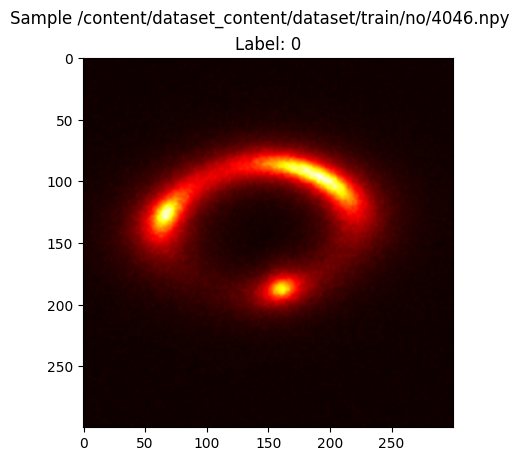

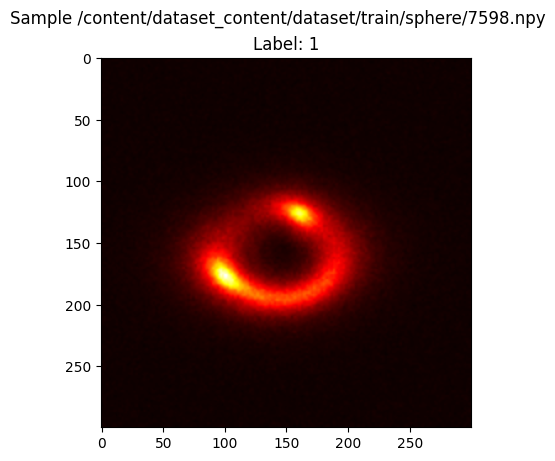

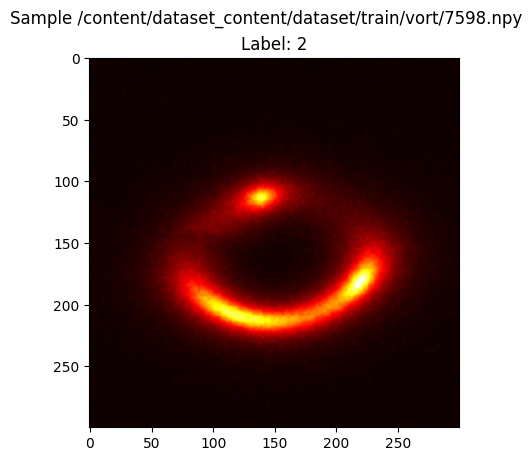

In [17]:
mape=[989,19000,29000]
for i in mape:
    img, label = train_dataset[i]
    plt.imshow(img[0], cmap="hot")
    plt.title(f"Label: {label}")
    plt.suptitle(f"Sample {train_dataset.data[i]}")
    plt.show()

In [18]:
model = models.efficientnet_b3(weights='DEFAULT')

num_ftrs = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(num_ftrs, 3)
)

model = model.to(device)

In [19]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
from torch.optim.lr_scheduler import CosineAnnealingLR
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = CosineAnnealingLR(optimizer, T_max=10) # T_max = number of epochs

In [20]:
def train_model(model, train_loader, val_loader, epochs=10):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        scheduler.step()                       # update learning rate after each epoch

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [21]:
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=10)

Epoch 1/10 | Train Loss: 0.9387 | Val Loss: 0.6823
Epoch 2/10 | Train Loss: 0.6220 | Val Loss: 0.5625
Epoch 3/10 | Train Loss: 0.5123 | Val Loss: 0.5222
Epoch 4/10 | Train Loss: 0.4505 | Val Loss: 0.4995
Epoch 5/10 | Train Loss: 0.4061 | Val Loss: 0.4722
Epoch 6/10 | Train Loss: 0.3732 | Val Loss: 0.4709
Epoch 7/10 | Train Loss: 0.3492 | Val Loss: 0.4872
Epoch 8/10 | Train Loss: 0.3363 | Val Loss: 0.4807
Epoch 9/10 | Train Loss: 0.3272 | Val Loss: 0.4771
Epoch 10/10 | Train Loss: 0.3246 | Val Loss: 0.4755


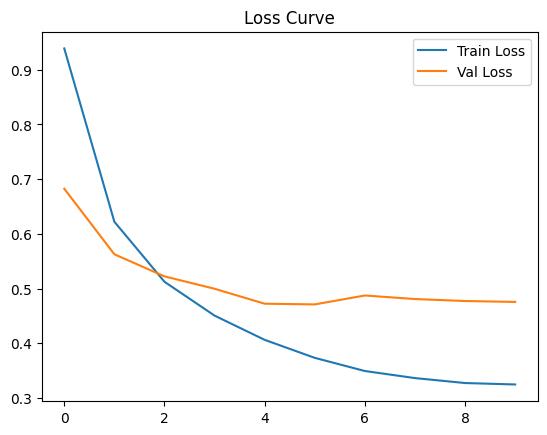

In [24]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

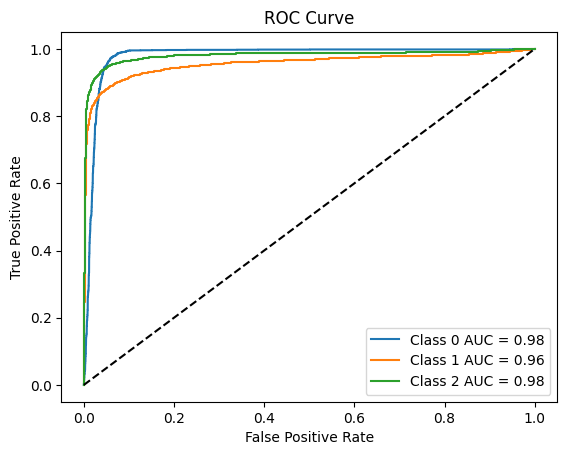

In [23]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.vstack(all_probs)
all_labels = np.hstack(all_labels)

# One-hot encode labels
all_labels_bin = label_binarize(all_labels, classes=[0,1,2])

# ROC curve
for i in range(3):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {i} AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [25]:
torch.save(model.state_dict(), "model.pth")